# 1. dataset preprocessing


##1.1 Dataset

###1.1.1 dataset downloading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/DataSets2/'

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

###1.1.2 picture preprocesing:Resize and Normalizing

In [ ]:
##transformation

import torchvision.transforms as transforms

pre_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],std=[0.26862954, 0.26130258, 0.27577711])
])

In [ ]:
##dataset downloading
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

tr_dataset=datasets.CIFAR10(root=path, train=True, download=True, transform=pre_transform)
test_dataset=datasets.CIFAR10(root=path, train=False, download=True, transform=pre_transform)
#45,000 for training, 5,000 for validation
train_size=int(0.9 * len(tr_dataset))
val_size=len(tr_dataset)-train_size
train_dataset, val_dataset=random_split(tr_dataset, [train_size, val_size])

#DataLoaders
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader=DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)


###1.1.3 showing an example


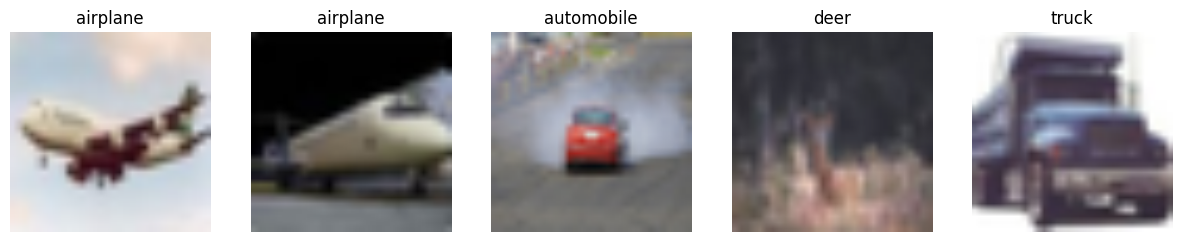

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random

clip_mean=[0.48145466, 0.4578275, 0.40821073]
clip_std=[0.26862954, 0.26130258, 0.27577711]

def NOnormalize(img_tensor):
    mean=torch.tensor(clip_mean).view(3, 1, 1)
    std=torch.tensor(clip_std).view(3, 1, 1)
    #normalized=(img - mean)/std
    return img_tensor* std + mean

# Showing 5 random samples 
class_names=tr_dataset.classes
fig, axs=plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
  ##avoiding to show first 5 samples
    idx=random.randint(0, len(tr_dataset)-1)
  ##getting image and its label
    image, label=tr_dataset[idx]
  ##unNormalize
    image=NOnormalize(image).permute(1, 2, 0).numpy()
    axs[i].imshow(np.clip(image, 0, 1))
  ##showing the label
    axs[i].set_title(class_names[label])
    axs[i].axis('off')
plt.show()

##1.2 Preparing CLIP and RESNET

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

##clip model and its processor from hugging face
from transformers import CLIPProcessor, CLIPModel
clip_model_name="openai/clip-vit-base-patch32"
##pretrained weights
clip_model=CLIPModel.from_pretrained(clip_model_name)
clip_processor=CLIPProcessor.from_pretrained(clip_model_name)

clip_model=clip_model.to(device)
clip_model.eval()

##Resnet 20
target_model=torch.hub.load("chenyaofo/pytorch-cifar-models","cifar10_resnet20",pretrained=True)
target_model=target_model.to(device)
target_model.eval()

##making text vector
c10_classes=tr_dataset.classes
##we make texts like the cIfar_10 format, looping over c10 classes and making text prompt
text_prompts=[f"a photo of a {label}" for label in c10_classes]
##tokenaizing our text prompts 
text_inputs=clip_processor(text=text_prompts, return_tensors="pt", padding=True).to(device)
##running the text encoder on the tokenized prompts
with torch.no_grad():
    text_features = clip_model.get_text_features(**text_inputs)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt

  0%|          | 0.00/1.09M [00:00<?, ?B/s]
 23%|█

## 1.3 Clean pic test

In [12]:
##PGD attack
import torchattacks
pgd_attack = torchattacks.PGD( target_model, eps=8/255, alpha=2/255, steps=7)

In [ ]:
!source /content/drive/MyDrive/virtual_env/bin/activate; pip install torchattacks

/bin/bash: line 1: /content/drive/MyDrive/virtual_env/bin/activate: No such file or directory
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [13]:
import torch.nn.functional as F
def model_evaluation(dataloader, clip_model, attacker, text_features, device, adv=False):
    correct=0
    total=0
    clip_model.eval()

    for images, labels in dataloader:
        images=images.to(device)
        labels=labels.to(device)

        if adv:
            images=attacker(images, labels)

        with torch.no_grad():
            image_features=clip_model.get_image_features(images)
            image_features=F.normalize(image_features, dim=1)
            logits=image_features @ F.normalize(text_features, dim=1).T
            predictions=torch.argmax(logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        accuracy_percent=100*(correct/total)

    return accuracy_percent

In [14]:
clean_acc=model_evaluation(test_loader, clip_model, pgd_attack, text_features, device, adv=False)


In [15]:
print(f"Clean Accuracy={clean_acc:.2f}%")

Clean Accuracy=87.83%


In [17]:
adv_acc=model_evaluation(test_loader, clip_model, pgd_attack, text_features, device, adv=True)

In [18]:
print(f"Adversarial Accuracy={adv_acc:.2f}%")

Adversarial Accuracy=55.22%


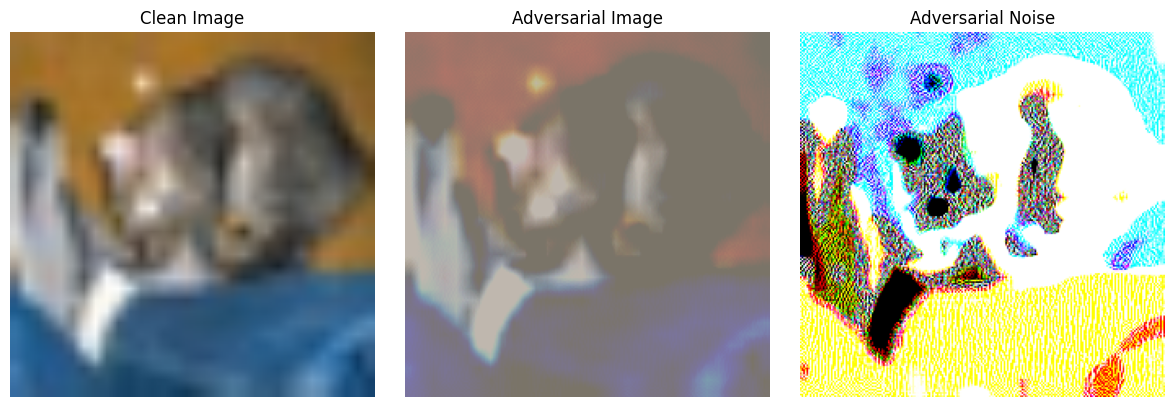

In [ ]:
##showing samples
import matplotlib.pyplot as plt

#getting our sample
image, label = next(iter(test_loader))
image=image[0:1].to(device)
label=label[0].item()

#making adversarial data
advers_image=pgd_attack(image, torch.tensor([label]).to(device))

#noise calculation
attack_noise=advers_image-image

#un normalizing
clip_mean=[0.48145466, 0.4578275, 0.40821073]
clip_std=[0.26862954, 0.26130258, 0.27577711]

def clip1_unnormalize(img_tensor):
    mean=torch.tensor(clip_mean).view(3, 1, 1).to(device)
    std=torch.tensor(clip_std).view(3, 1, 1).to(device)
    return (img_tensor * std + mean).clamp(0, 1)


img_clean=clip1_unnormalize(image[0]).permute(1, 2, 0).cpu().numpy()
img_adv=clip1_unnormalize(advers_image[0]).permute(1, 2, 0).cpu().numpy()
img_noise=(attack_noise[0]/(8/255)/2 + 0.5).permute(1, 2, 0).detach().cpu().numpy() 

# plotting
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Clean Image")
plt.imshow(img_clean)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Adversarial Image")
plt.imshow(img_adv)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Adversarial Noise")
plt.imshow(img_noise)
plt.axis("off")

plt.tight_layout()
plt.show()